In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":12})
# rc('text', usetex=True)

In [2]:
experiment_name = ExperimentName.kl_newsvendor_1d
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/{experiment_name.value}")
experiment_dir = Path(f"/dcs/large/u1508153/misdro/{experiment_name.value}")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
for _, row in all_results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "kl_dro_bas":
        num_total_samples.append(row["num_likelihood_samples"])
all_results_df["num_total_samples"] = num_total_samples

In [3]:
# NOTE filter by DGP
filter_dgp = "contaminated_exp"
results_df = all_results_df.loc[all_results_df["dgp"] == filter_dgp]

# NOTE filter out when log_partition_constant G is less than epsilon
results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

results_df

mean_cost     var_cost  \
uuid                                 replication                            
f52762ad-0fa3-4be7-93de-fd2f81f6853a 0             77.614746   604.126922   
                                     1             75.042855   687.308378   
                                     2             62.131164   836.687302   
                                     3             50.316671   914.228633   
                                     4            103.388634   685.385724   
...                                                      ...          ...   
35879cbc-18ad-4b2e-bde9-774f4d42550e 195          212.261919  1023.503374   
                                     196          166.078280   608.042652   
                                     197          201.428755  1309.403211   
                                     198           86.825472   709.888298   
                                     199          214.176202   758.435046   

                                                   solution  dgp_time  \
uuid                                 replication                        
f52762ad-0fa3-4be7-93de-fd2f81f6853a 0            35.719886  0.000309   
                                     1            32.651199  0.000326   
                                     2            29.416417  0.000348   
                                     3            23.454727  0.000391   
                                     4            43.959369  0.000308   
...                                                     ...       ...   
35879cbc-18ad-4b2e-bde9-774f4d42550e 195          80.883094  0.000595   
                                     196          62.962937  0.000415   
                                     197          79.209832  0.000358   
                                     198          38.579425  0.000507   
                                     199          82.080815  0.000518   

                                                  likelihood_time  \
uuid                                 replication                    
f52762ad-0fa3-4be7-93de-fd2f81f6853a 0                   0.000070   
                                     1                   0.000067   
                                     2                   0.000074   
                                     3                   0.000078   
                                     4                   0.000067   
...                                                           ...   
35879cbc-18ad-4b2e-bde9-774f4d42550e 195                 0.004376   
                                     196                 0.002407   
                                     197                 0.002750   
                                     198                 0.002919   
                                     199                 0.002723   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
f52762ad-0fa3-4be7-93de-fd2f81f6853a 0                  0.000030    0.148026   
                                     1                  0.000032    0.037985   
                                     2                  0.000033    0.026212   
                                     3                  0.000033    0.031264   
                                     4                  0.000029    0.032891   
...                                                          ...         ...   
35879cbc-18ad-4b2e-bde9-774f4d42550e 195                0.000169    0.948364   
                                     196                0.000111    0.751532   
                                     197                0.000100    0.831697   
                                     198                0.000118    0.861347   
                                     199                0.000155    0.801023   

                                                  setup_time  \
uuid                                 replication               
f52762ad-0fa3-4be7-93de-fd2f81f6

In [4]:
# agg_df = gb.agg({
#     "mean_cost": ["mean", "var"],
#     "var_cost": ["mean"],
#     "posterior_time": ["mean"],
#     "setup_time": ["mean"],
#     "solve_time": ["mean"],
    # "solution": ["mean", "var"],
# })

agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "inference", "posterior", "num_posterior_samples", "num_likelihood_samples"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:288: FutureWarning: The provided callable <function mean at 0x7f151c035b20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:288: FutureWarning: The provided callable <function var at 0x7f151c035da0> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:288: FutureWarning: The provided callable <function mean at 0x7f151c035b20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis

out_of_sample_mean  \
algorithm  dgp              epsilon inference posterior num_posterior_samples num_likelihood_samples                       
kl_bdro    contaminated_exp 0.001   bayes     gamma     5                     5                                68.475758   
                                                        10                    10                               64.873816   
                                                        30                    30                               64.444529   
                                                        50                    50                               64.020485   
                            0.002   bayes     gamma     5                     5                                68.467575   
...                                                                                                                  ...   
kl_dro_bas contaminated_exp 2.500   bayes     gamma     1                     2500                            253.744225   
                            3.000   bayes     gamma     1                     25                              144.700708   
                                                                              100                             191.498774   
                                                                              900                             242.627590   
                                                                              2500                            254.854625   

                                                                                                      out_of_sample_mean_of_vars  \
algorithm  dgp              epsilon inference posterior num_posterior_samples num_likelihood_samples                               
kl_bdro    contaminated_exp 0.001   bayes     gamma     5                     5                                      1088.002165   
                                                        10                    10                                     1010.175198   
                                                        30                    30                                      981.450474   
                                                        50                    50                                      974.975406   
                            0.002   bayes     gamma     5                     5                                      1088.525534   
...                                                                                                                          ...   
kl_dro_bas contaminated_exp 2.500   bayes     gamma     1                     2500                                    868.864140   
                            3.000   bayes     gamma     1                     25                                      842.342256   
                                                                              100                                     835.948388   
                                                                              900                                     861.651512   
                                                                              2500                                    869.284269   

                                                                                                      out_of_sample_var_of_means  \
algorithm  dgp              epsilon inference posterior num_posterior_samples num_likelihood_samples                               
kl_bdro    contaminated_exp 0.001   bayes     gamma     5                     5                                       994.592529   
                                                        10                    10                                      484.580920   
                                                        30                    30                                      370.413292   
                                                        50                    50                                

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

/tmp/dcs-tmp.u1508153/ipykernel_771450/3139649320.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/dcs-tmp.u1508153/ipykernel_771450/3139649320.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_minim

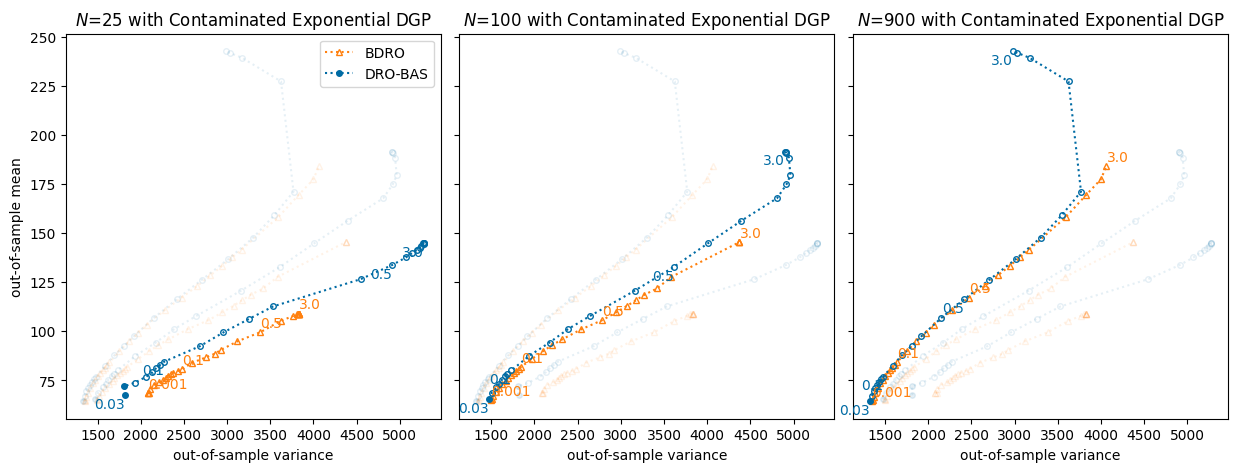

In [5]:
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

TOTAL_SAMPLES = [25, 100, 900]

nrows = len(agg_df.index.get_level_values("dgp").unique())
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
# fig.suptitle(NiceNameDGP[filter_dgp], fontsize=12)

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[(
        (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
        | (likelihood_sr == total_samples) & (posterior_sr == 1)
    )]
    df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    gb = df.groupby("dgp")

    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
            axes[k].set_title("$N$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        else:
            alpha = 0.1
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                    group_df.index.get_level_values("inference"),
                    group_df.index.get_level_values("posterior"),
                )
            )
            if k == 0:
                axes[k].set_ylabel("out-of-sample mean")
                axes[k].legend()
            axes[k].set_xlabel("out-of-sample variance")
            
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp, inference, posterior in index_set:
                style = algorithm_style(algorithm)
                line_label = ""
                if k == 0 and j == k:
                    line_label = style.pop("label")
                else:
                    style.pop("label")
                mean_variance_plot(axes[k], group_df.loc[algorithm, dgp, :np.inf, inference, posterior], **style, alpha=alpha, is_labelled=is_labelled, label=line_label)
# fig.savefig(f"/Users/patrick/downloads/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")
fig.show()

## Solve time

In [6]:
results_df["is_warm_start"] = results_df.index.get_level_values("replication") == 0

# solve_time_df = results_df.groupby(["algorithm", "dgp", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="dgp").unstack(level="algorithm")
solve_time_df = results_df.groupby(["algorithm", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="algorithm").swaplevel(1,2, axis="columns")

solve_time_df


solve_time                                
algorithm                           kl_bdro kl_dro_bas   kl_bdro kl_dro_bas
                                       mean       mean       std        std
num_total_samples is_warm_start                                            
25                False            0.010642   0.012583  0.002658   0.002770
                  True             0.071467   0.030712  0.030127   0.025637
100               False            0.028822   0.025765  0.004106   0.006646
                  True             0.164283   0.037604  0.026229   0.002002
900               False            0.283199   0.467773  0.033372   0.154062
                  True             5.645570   0.291211  0.071242   0.024560
2500              False            1.174407   2.180521  0.193975   0.587862
                  True           100.959922   1.162853  0.709166   0.090489

In [7]:
print(solve_time_df.to_latex())

\begin{tabular}{llrrrr}
\toprule
 &  & \multicolumn{4}{r}{solve_time} \\
 & algorithm & kl_bdro & kl_dro_bas & kl_bdro & kl_dro_bas \\
 &  & mean & mean & std & std \\
num_total_samples & is_warm_start &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{25} & False & 0.010642 & 0.012583 & 0.002658 & 0.002770 \\
 & True & 0.071467 & 0.030712 & 0.030127 & 0.025637 \\
\cline{1-6}
\multirow[t]{2}{*}{100} & False & 0.028822 & 0.025765 & 0.004106 & 0.006646 \\
 & True & 0.164283 & 0.037604 & 0.026229 & 0.002002 \\
\cline{1-6}
\multirow[t]{2}{*}{900} & False & 0.283199 & 0.467773 & 0.033372 & 0.154062 \\
 & True & 5.645570 & 0.291211 & 0.071242 & 0.024560 \\
\cline{1-6}
\multirow[t]{2}{*}{2500} & False & 1.174407 & 2.180521 & 0.193975 & 0.587862 \\
 & True & 100.959922 & 1.162853 & 0.709166 & 0.090489 \\
\cline{1-6}
\bottomrule
\end{tabular}



# Constant $G(\tau_n)$ and expected KL

In [8]:

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_log_partition_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_log_partition_constant("normal_gamma", theta_posterior)

dgp = "multivariate_normal"
posterior = "normal_inverse_wishart"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_log_partition_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

ValueError: Dimension mismatch: array 'cov' is of shape (1, 1), but 'mean' is a vector of length 5.

In [ ]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.08892539135699731, 0.0022999465683889984)

In [ ]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.7442957726813, 0.0)

# Mean squared error between our solution and the solution under the DGP


In [ ]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 809.5869569415518, 16.31412063772674)

In [ ]:
def multivariate_digamma(a: float, p: int) -> float:
    """The multivariate digamma function of dimension p

    Notes:
        [1] https://search.r-project.org/CRAN/refmans/CholWishart/html/mvdigamma.html
        [2] https://en.wikipedia.org/wiki/Multivariate_gamma_function#Derivatives
    """
    return np.sum([sp.special.digamma(a + (1.0-i)/2.0) for i in range(p)])

def get_normal_inverse_wishart_G_constant(dim: int, kappa_post: float) -> float:
    """Returns the constant G(tau, nu) for the normal-inverse-Wishart"""
    term1 = -0.5 * dim * np.log(2)
    print(term1)
    term2 = - 0.5 * multivariate_digamma(0.5 * (kappa_post - dim - 2), dim)
    print(term2)
    term3 = dim / (2 * kappa_post)
    print(term3)
    term4 = dim * 0.5 * np.log(kappa_post - dim - 2)
    print(term4)
    # term5 = 0.5 * np.log(dim)
    # print(term5)
    return term1 + term2 + term3 + term4

In [ ]:
dim = 5
_, kappa_prior, _, _ = default_prior_params("normal_inverse_wishart", dim=dim)
kappa_post = kappa_prior +  20
kappa_prior, kappa_post

(13.0, 33.0)

In [ ]:
get_normal_inverse_wishart_G_constant(dim, kappa_post)

-1.7328679513998633
-6.208643562685282
0.07575757575757576
8.145241345053705


0.2794874067261359